<a href="https://colab.research.google.com/github/Karthik5412/100-pandas-puzzles/blob/master/dl_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/drive/')


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [2]:
import zipfile
from pathlib import Path
extract_path = Path("/content/extracted_data")

with zipfile.ZipFile('/content/drive/MyDrive/Deep_Learning/custumes/archive (23).zip', 'r') as ref:
    ref.extractall('extracted_data')

In [14]:
from tensorflow.keras.utils import image_dataset_from_directory

train_ds = image_dataset_from_directory('/content/extracted_data/clothing-dataset-small/train',labels='inferred',label_mode='int', color_mode='rgb', seed=123,image_size=(224,224), batch_size=32)

test_ds = image_dataset_from_directory('/content/extracted_data/clothing-dataset-small/test',labels='inferred',label_mode='int', color_mode='rgb', seed=123,image_size=(224,224), batch_size=32)

Found 3068 files belonging to 10 classes.
Found 372 files belonging to 10 classes.


In [4]:
import pandas as pd
import numpy as np

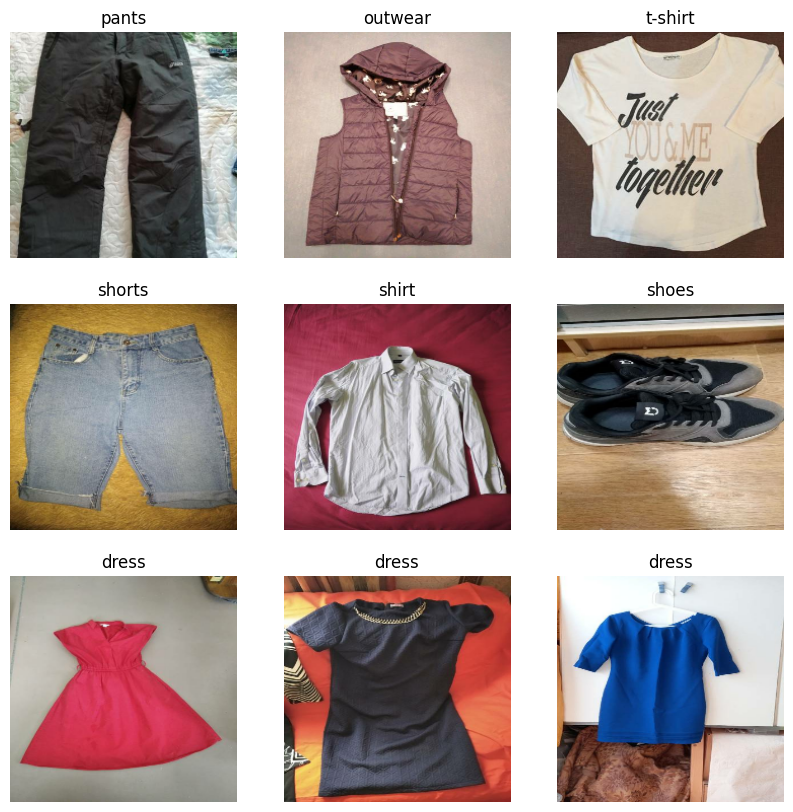

In [15]:
import matplotlib.pyplot as plt

class_names = train_ds.class_names
plt.figure(figsize=(10,10))

for img,label in train_ds.take(1):
    for i in range(0,9):
        plt.subplot(3,3,i+1)

        plt.imshow(img[i].numpy().astype('uint8'))
        plt.title(class_names[label[i]])
        plt.axis('off')





In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [17]:
gen = ImageDataGenerator(
    rotation_range=45,
    zoom_range=0.3,
    height_shift_range=0.2,
    width_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    save_format='jpeg'
)

In [20]:
aug = gen.flow_from_directory(
    '/content/extracted_data/clothing-dataset-small/train',
    target_size=(224,224),
    batch_size=16,
    save_to_dir='/content/extracted_data/clothing-dataset-small/augumented',
    class_mode='categorical',
    save_prefix='aug_'
    )

Found 3068 images belonging to 10 classes.


In [22]:
for i in range(10):
    next(aug)

In [54]:
from tensorflow.keras import layers
from tensorflow.keras import Sequential

aug = Sequential([
    layers.RandomRotation(0.2, input_shape=(224,224,3),fill_mode='wrap'),
    layers.RandomFlip('horizontal'),
    layers.RandomZoom(0.3),
    layers.RandomTranslation(height_factor=0.2, width_factor=0.2)
])

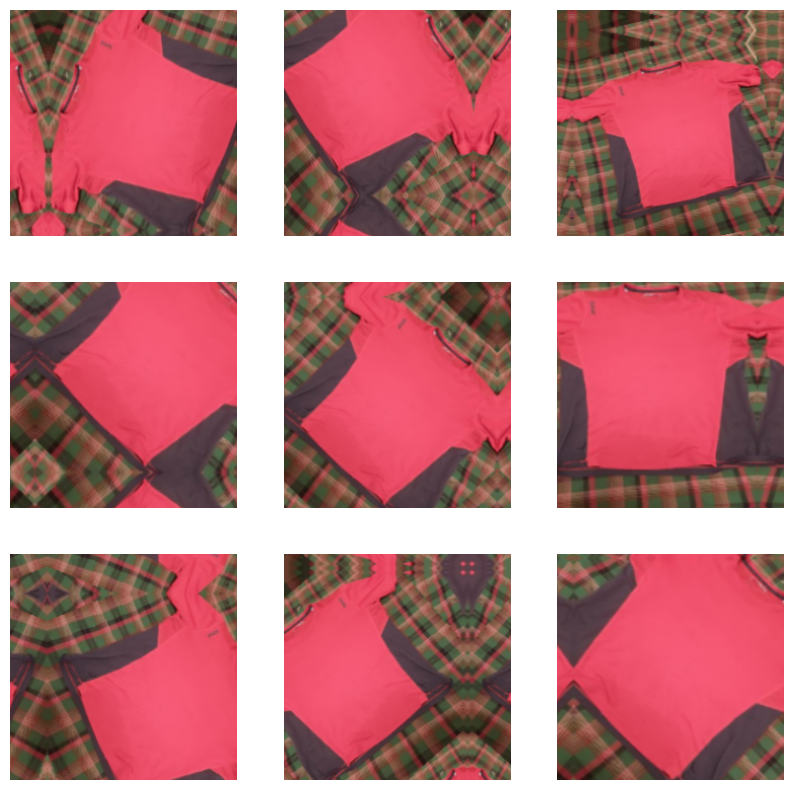

In [55]:
import tensorflow as tf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for img,labels in train_ds.take(1):

    for i in range(9):
        agumented = aug(img)
        plt.subplot(3,3,i+1)
        plt.imshow(agumented[4].numpy().astype('uint8'))
        plt.axis('off')